# 04 — CSP: Asignación de Variedades de Café a Parcelas

Este notebook demuestra el módulo `src/csp/crop_allocation.py`.

**Técnica:** Backtracking con restricciones (*Constraint Satisfaction Problem*) usando la librería `python-constraint`.

**Restricciones implementadas:**
- Rangos de altitud por variedad
- pH del suelo entre 5.5 y 7.0

| Variedad | Altitud (msnm) |
|---|---|
| Arabica  | 1200 – 2000 |
| Robusta  | 0 – 800 |
| Bourbon  | 1200 – 1800 |
| Caturra  | 1000 – 1700 |
| Catuai   | 1000 – 1800 |

In [4]:
%pip install python-constraint pandas matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from src.csp.crop_allocation import solve_farm_csp, _variedades_validas
import pandas as pd

print("Módulo CSP importado correctamente.")

Módulo CSP importado correctamente.


## 1. Caso base — finca con 5 parcelas en diferentes altitudes

In [9]:
parcelas_base = [
    {"id": "A", "altitud": 1500, "ph": 6.2, "sombra": 0.5},  # alta montaña
    {"id": "B", "altitud": 1350, "ph": 6.0, "sombra": 0.4},
    {"id": "C", "altitud": 1100, "ph": 6.5, "sombra": 0.3},
    {"id": "D", "altitud":  600, "ph": 6.8, "sombra": 0.2},  # zona baja → Robusta
    {"id": "E", "altitud": 1650, "ph": 5.8, "sombra": 0.6},
]

solucion = solve_farm_csp(parcelas_base)

# Mostrar resultado enriquecido
filas = []
for p in parcelas_base:
    opciones = _variedades_validas(p, ["Arabica", "Robusta", "Bourbon", "Caturra", "Catuai"])
    filas.append({
        "Parcela":             p["id"],
        "Altitud (msnm)":      p["altitud"],
        "pH":                  p["ph"],
        "Variedades válidas":  ", ".join(opciones),
        "Asignada":            solucion.get(p["id"], "—"),
    })

pd.DataFrame(filas)

,Parcela,Altitud (msnm),pH,Variedades válidas,Asignada
0,A,1500,6.2,"Arabica, Bourbon, Caturra, Catuai",Catuai
1,B,1350,6.0,"Arabica, Bourbon, Caturra, Catuai",Catuai
2,C,1100,6.5,"Caturra, Catuai",Catuai
3,D,600,6.8,Robusta,Robusta
4,E,1650,5.8,"Arabica, Bourbon, Caturra, Catuai",Catuai


## 2. Visualización — altitud vs. variedad asignada

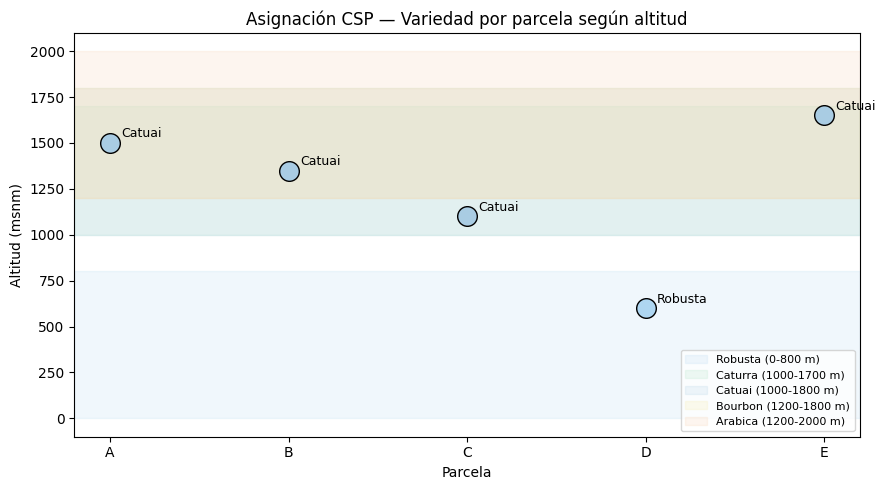

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Rangos de altitud por variedad (bandas de fondo)
rangos = {
    "Robusta":  (0,    800,  "#aed6f1"),
    "Caturra":  (1000, 1700, "#a9dfbf"),
    "Catuai":   (1000, 1800, "#a9cce3"),
    "Bourbon":  (1200, 1800, "#f9e79f"),
    "Arabica":  (1200, 2000, "#f5cba7"),
}
colores_var = {v: c for v, (_, __, c) in rangos.items()}

fig, ax = plt.subplots(figsize=(9, 5))

# Bandas de rango
for variedad, (lo, hi, color) in rangos.items():
    ax.axhspan(lo, hi, alpha=0.18, color=color, label=f"{variedad} ({lo}-{hi} m)")

# Parcelas
for p in parcelas_base:
    var_asig = solucion.get(p["id"], "—")
    color = colores_var.get(var_asig, "#888")
    ax.scatter(p["id"], p["altitud"], s=200, color=color, zorder=5, edgecolors="black")
    ax.annotate(var_asig, (p["id"], p["altitud"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Parcela")
ax.set_ylabel("Altitud (msnm)")
ax.set_title("Asignación CSP — Variedad por parcela según altitud")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Casos extremos — pH fuera de rango y altitud sin variedad válida

In [8]:
# Caso 1: pH ácido (4.5) → ninguna variedad cumple → fallback a todas
p_acido = {"id": "X", "altitud": 1400, "ph": 4.5, "sombra": 0.5}
vars_acido = _variedades_validas(p_acido, ["Arabica", "Robusta", "Bourbon", "Caturra", "Catuai"])
print("pH 4.5 — variedades válidas (con fallback):", vars_acido)

# Caso 2: altitud 900 m → solo Caturra y Catuai si pH es correcto
p_media = {"id": "Y", "altitud": 900, "ph": 6.3, "sombra": 0.4}
vars_media = _variedades_validas(p_media, ["Arabica", "Robusta", "Bourbon", "Caturra", "Catuai"])
print("Altitud 900 m — variedades válidas:", vars_media)

# Caso 3: finca completa insoluble (todas las parcelas en zona media con pH muy básico)
parcelas_borde = [
    {"id": "F", "altitud": 900, "ph": 7.5, "sombra": 0.3},  # pH alto, altitud media
    {"id": "G", "altitud": 850, "ph": 7.8, "sombra": 0.4},
]
sol_borde = solve_farm_csp(parcelas_borde)
print("\nFinca con restricciones difíciles:", sol_borde)

pH 4.5 — variedades válidas (con fallback): ['Arabica', 'Robusta', 'Bourbon', 'Caturra', 'Catuai']
Altitud 900 m — variedades válidas: ['Arabica', 'Robusta', 'Bourbon', 'Caturra', 'Catuai']

Finca con restricciones difíciles: {'F': 'Catuai', 'G': 'Catuai'}
